In [2]:
!pip install gymnasium
!pip install git+https://github.com/DLR-RM/stable-baselines3

Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 952.1/952.1 KB 4.7 MB/s eta 0:00:0000:0100:01
  Using cached Farama_Notifications-0.0.4-py3-none-any.whl (2.5 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl (44 kB)
Defaulting to user installation because normal site-packages is not writeable
  Cloning https://github.com/DLR-RM/stable-baselines3 to /tmp/pip-req-build-gprszehl
  Running command git clone --filter=blob:none --quiet https://github.com/DLR-RM/stable-baselines3 /tmp/pip-req-build-gprszehl
  Resolved https://github.com/DLR-RM/stable-baselines3 to commit cc20f5af0cfec798d8c8d26bc9886b1a38ead90c
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 915.5/915.5 MB 911.4 kB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 17.7 MB/s eta 0:00:

In [8]:
!pip install numpy>=1.24.0

In [9]:
np.__version__

'1.21.5'

In [1]:
import numpy as np
import gymnasium as gym
from typing import Optional
import matplotlib.pyplot as plt

In [51]:
def wrap_angle_to_pi(angle):
    return np.arctan2(np.sin(angle), np.cos(angle))


class Controller:
  def __init__(self, k_rho=15, k_alpha=5, k_beta=-2) -> None:
    self.k_rho = k_rho
    self.k_alpha = k_alpha
    self.k_beta = k_beta

  def get_cmds(self, rho, alpha, beta):
    """
      This function applies the control low v = k*rho and w = k*alpha + k*beta
      given angle errors

      input:
      - rho: distance to target pos
        - bearing angle alpha between robot and target pos
        - beta: goal heading in world frame

      output:
      - v: linear speed of the robot
      - omega: angular speed of the unicycle robot
    """
    v = self.k_rho*rho
    omega = self.k_beta*beta + self.k_alpha*alpha

    return v, omega

class Robot:
  def __init__(self, L=1, max_speed=(2.0, 1.0)) -> None:

    self.config = np.array([0., 0., 0.])
    self.speed = np.array([0.0, 0.0, 0.0])

    self.L = L # length of the robot car
    self.delta_t = 0.02 # second
    self.max_speed = max_speed

  def update_bicycle(self, v, gamma):
    """
      This function implements the bicycle model kinematics.
      Given inputs commands v and gamma, it computes the new
      configuration of the robot from the current configuration
      using the euler integration

      x = x + x_dot*delta_t
      y = y + y_dot*delta_t
      theta = theta + theta_dot*delta_t

      input:
        - speed v
        - steering angle gamma

      action:
        - update configuration at time step t+1
    """
    x_dot = v*np.cos(self.config[2]) # v*cos(theta)
    y_dot = v*np.sin(self.config[2]) # v*sin(theta)
    theta_dot = (v/self.L)*np.tan(gamma) # v*tan(gamma)/L
    theta_dot = np.clip(theta_dot, -self.max_speed[1], self.max_speed[1])

    self.speed[0] = x_dot.copy()
    self.speed[1] = y_dot.copy()

    self.speed[2] = theta_dot

    self.config[0] = self.config[0] + x_dot*self.delta_t
    self.config[1] = self.config[1] + y_dot*self.delta_t
    self.config[2] = self.config[2] + theta_dot*self.delta_t

    self.config[2] = wrap_angle_to_pi(self.config[2])

    return


  def uni2bicycle(self, v, omega):
    """
      This function transform commands inputs (v, omega) for unicycle robot to
      bicycle robot (v, gamma)

      input:
        - v: linear speed
        - omega: angular speed

      output:
        - v: same linear speed
        - gamma: steering angle of the front wheel
    """
    val = omega*self.L/(v+1e-6)
    gamma = np.arctan2(np.sin(val), np.cos(val))

    return v, gamma

  def cartesian2polar(self, delta_x, delta_y):
    """
      This function takes as input delta_x and delta_x and
      compute the polar coordinates rho, alpha, beta for the
      control

      input:
        - delta_x: x coordinate
        - delta_y: y coordinate

      output:
        - alpha: angle of delta_x and delta_y in robot frame
        - rho: norm of the vector (delta_x, delta_y)
        - beta: angle of goal in world frame
    """
    rho = np.linalg.norm(np.array([delta_x, delta_y]))
    alpha = np.arctan2(delta_y, delta_x) - self.config[2]
    alpha = wrap_angle_to_pi(alpha)

    beta = -(alpha + self.config[2])
    beta = wrap_angle_to_pi(beta)


    return rho, alpha, beta

  def update_kinematics(self, v, omega):
    """
      This function implements one step update of the kinematic model
    """


    #print(f"config: {v, omega}")
    # 5. transform to bicycle model commands v and gamma
    v, gamma = self.uni2bicycle(v, omega)

    # 6. update robot kinematic using bicycle model
    self.update_bicycle(v, gamma)

In [ ]:
class ParkingTask(gym.Env):
  def __init__(self, config=None) -> None:

    self.action_space = gym.spaces.Box(low=-1, high=1, shape=(2, ))
    self.observation_space = gym.spaces.Box(low=-1, high=1, shape=(6, ))
    self.robot = Robot()

    self.target_config = np.array([0., 0., 0.])
    self.start_config = np.array([0., 0., 0.])

    self.prev_distance_to_target = 0
    self.distance_to_target = 0
    self.bearing = 0
    self.target_bearing = 0
    self.initial_distance_to_target = 0


    self.grid_size = (10, 10)
    self.weights = {"dist": 20., "bearing": -4., "orient":1.5}

    self.time = 0
    self.max_time_step = 20
    self.step_dt = 0.02
    self.robot.delta_t = self.step_dt

    self.reward_dist = 0
    self.reward_bearing = 0
    self.reward_orient = 0
    self.reward_goal = 0
    self.reward_time = 0
    
  def _get_info(self):

    return {}

  def _get_obs(self):

    dx = self.target_config[0] - self.robot.config[0]
    dy = self.target_config[1] - self.robot.config[1]

    self.bearing = np.arctan2(dy, dx) - self.robot.config[2]
    self.bearing = (self.bearing + np.pi) % (2*np.pi) - np.pi
    self.bearing = wrap_angle_to_pi(self.bearing)

    
    self.target_bearing = np.arctan2(dy, dx) - self.target_config[2]
    self.target_bearing = wrap_angle_to_pi(self.target_bearing)

    self.distance_to_target = np.sqrt(dx**2 + dy**2)

    normalized_target_bearing = self.target_bearing/np.pi
    normalized_bearing = self.bearing/np.pi
    normalized_lin_speed = self.robot.speed[:2]/self.robot.max_speed[0]
    normalized_ang_speed = self.robot.speed[2]/self.robot.max_speed[1]
    normalized_distance = np.clip(self.distance_to_target/self.initial_distance_to_target, -1, 1)

    obs = np.array([
        normalized_target_bearing.item(), # 1
        normalized_bearing.item(), # 1
        normalized_distance.item(), # 1
        normalized_ang_speed.item(), # 1
        normalized_lin_speed[0].item(), # 1
        normalized_lin_speed[1].item() # 1
    ])
    
    return obs

  def reset(self, seed: Optional[int] = None, options: Optional[dict] = None):

    # IMPORTANT: Must call this first to seed the random number generator
    super().reset(seed=seed)


    self.target_config[:2] = np.random.uniform(low=6, high=7, size=(2, ))
    self.start_config[:2] = np.random.uniform(low=-1, high=1, size=(2, ))

    self.target_config[2] = np.random.uniform(-np.pi, np.pi)
    self.start_config[2] = np.random.uniform(-np.pi, np.pi)

    self.robot.config = self.start_config.copy()

    self.initial_distance_to_target = np.linalg.norm(self.target_config[:2]-self.start_config[:2])
    self.prev_distance_to_target = self.initial_distance_to_target

    self.time = 0

    obs = self._get_obs()
    info = self._get_info()

    return obs, info

  def _get_reward(self):

    #rew_dist = 0.03*self.weights["dist"]*self.robot.distance_to_target
    distance_progr = (1/self.step_dt)*(self.prev_distance_to_target - self.distance_to_target)/(self.robot.max_speed[0])
    rew_distance = 50*distance_progr
    
    self.reward_dist = rew_distance
    #rew_bearing = self.weights["bearing"]*np.abs(self.robot.bearing/np.pi)
    #y = np.exp(-4 * np.abs(x)) - 1
    rew_bearing =np.exp(-4 * np.abs(self.bearing)) - 1
    self.reward_bearing = rew_bearing
    #reward_goal = 100 if self.robot.distance_to_target<=0.02 else 0
    rew_time = -0.02
    self.reward_time = rew_time
    
    rew_goal = 15 if np.abs(self.distance_to_target)<=0.02 else 0
    self.reward_goal = rew_goal

    outbound = abs(self.robot.config[0]) > self.grid_size[0] or abs(self.robot.config[1]) > self.grid_size[1]
    rew_outbound = -1000 if outbound else 0

    rewards_total =  rew_time + rew_goal + rew_bearing + rew_distance #+ time_rew + rew_bearing #+ time_rew #+ rew_outbound + time_rew

    return rewards_total

  def step(self, action):

    v, omega = action
    
    v = v*self.robot.max_speed[0]
    omega = omega*self.robot.max_speed[1]
    
    v = np.clip(v, -self.robot.max_speed[0], self.robot.max_speed[0])
    omega = np.clip(omega, -self.robot.max_speed[1], self.robot.max_speed[1])

    self.robot.update_kinematics(v, omega)
    #print(f"pos: {self.robot.config}")

    self.time += self.step_dt

    outbound = abs(self.robot.config[0]) > self.grid_size[0] or abs(self.robot.config[1]) > self.grid_size[1]
    timeout = self.time > self.max_time_step

    terminated = self.distance_to_target<=0.02 #np.abs(self.robot.bearing)<=0.02 #
    
    #print(f"terminated: {terminated} bear: {self.robot.bearing}")
    truncated = timeout #| outbound
    self.timeout = (timeout, outbound)
    obs = self._get_obs()
    info = self._get_info()
    reward = self._get_reward()

    self.prev_distance_to_target = float(self.distance_to_target)

    return obs, reward, terminated, truncated, info

# Register the environment so we can create it with gym.make()
gym.register(
    id="gymnasium_env/ParkingTask-v0",
    entry_point=ParkingTask,
    #max_episode_steps=800,  # Prevent infinite episodes
)


/mnt/ssd-storage/fsangare/isaaclab/lib/python3.10/site-packages/gymnasium/envs/registration.py:648: UserWarning: WARN: Overriding environment gymnasium_env/ParkingTask-v0 already in registry.
  logger.warn(f"Overriding environment {new_spec.id} already in registry.")


truncate: False terminate: True outbound: (False, False) pos: [ 6.53241175  6.72439969 -0.5439004 ]
distance to target: 0.018810839021744182
final time: 6.659999999999946
episode_returns: 936.7162733212322
episode_length: 333


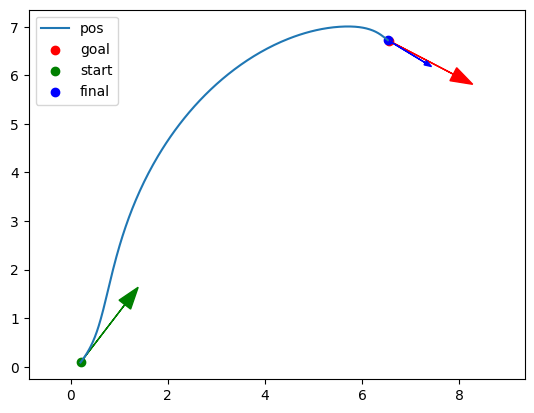

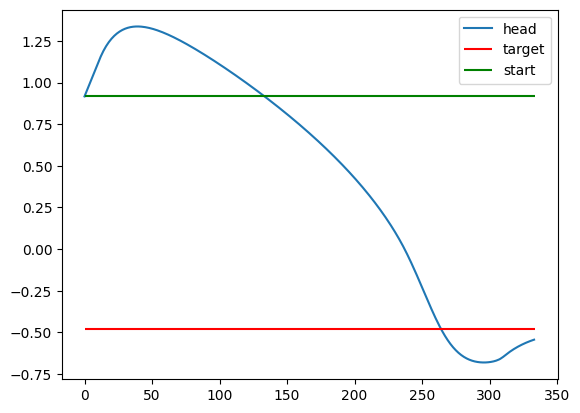

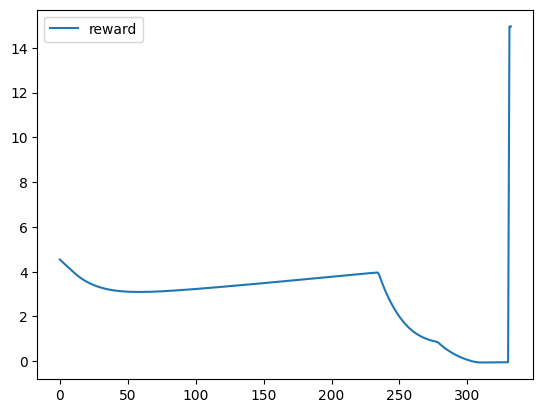

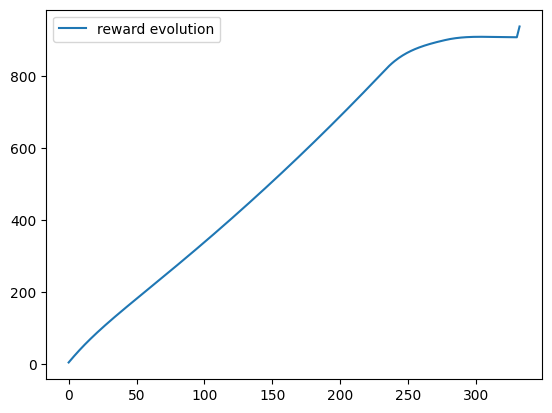

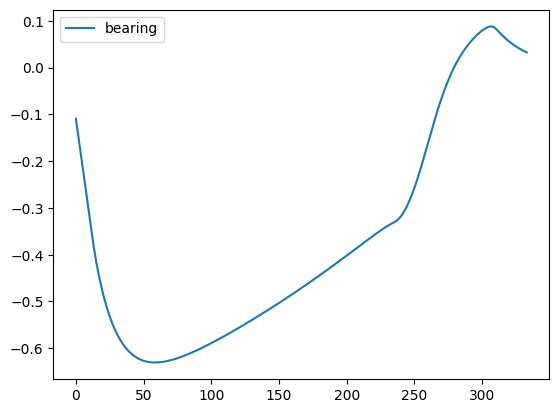

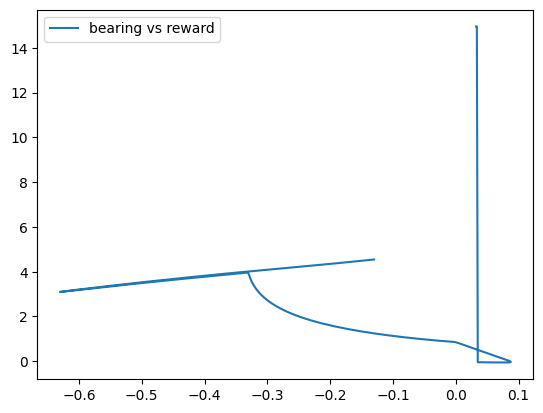

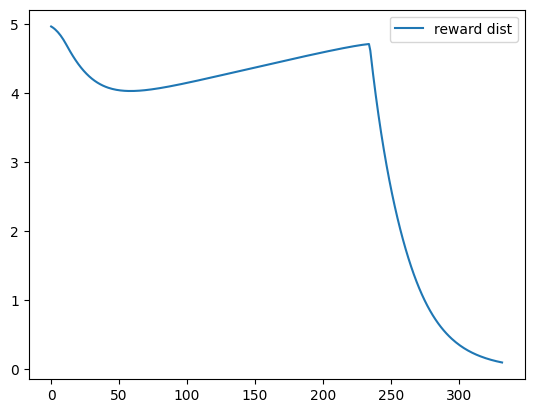

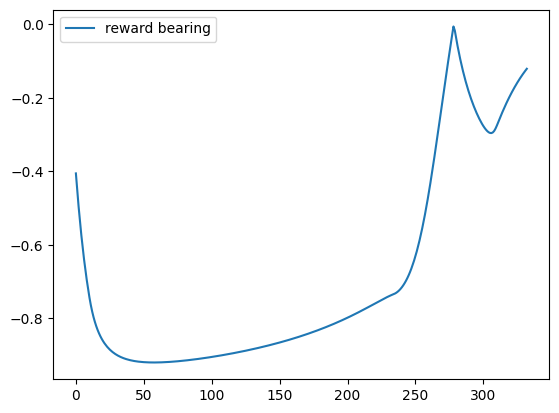

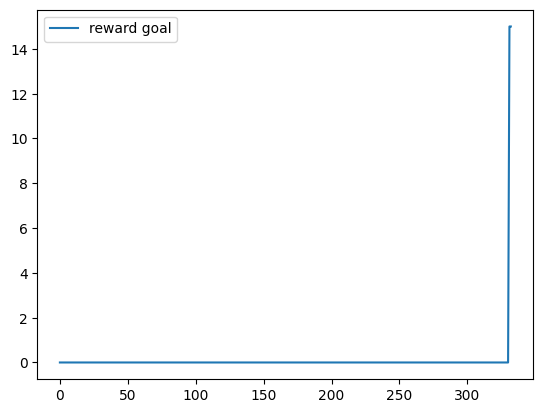

In [109]:
robot = Robot()
np.random.seed(np.random.randint(10))
envs = gym.make("gymnasium_env/ParkingTask-v0")
envs = gym.wrappers.RecordEpisodeStatistics(envs)
envs.unwrapped.robot.max_speed = (2., 1.0)
obs, info = envs.reset()


done = False
pos_traj = [envs.unwrapped.start_config[:2].copy()]
orientation_traj = [envs.unwrapped.start_config[2]]
bearing_traj = [envs.unwrapped.bearing.copy()]

rewards_episode = []
rewards_dist = []
rewards_bearing = []  
rewards_orient = []
rewards_goal = []

total_reward = 0
rewards_evolution = []

controller = Controller(k_rho=1, k_alpha=3, k_beta=-1.5)


while not done:

  dx = envs.unwrapped.target_config[0] - envs.unwrapped.robot.config[0]
  dy = envs.unwrapped.target_config[1] - envs.unwrapped.robot.config[1]

  rho, alpha, beta = envs.unwrapped.robot.cartesian2polar(dx, dy)

  # Add target angle to beta otherwise the final orientation will be missed
  beta = beta + envs.unwrapped.target_config[2]
  beta = wrap_angle_to_pi(beta)
  
  v, omega = controller.get_cmds(rho, alpha, beta)

  action = (v, omega)
  next_obs, rew, terminated, truncated, info = envs.step(action)
  total_reward += rew
  pos_traj.append(envs.unwrapped.robot.config[:2].copy())
  orientation_traj.append(envs.unwrapped.robot.config[2].copy())
  bearing_traj.append(envs.unwrapped.bearing.copy())
  
  done = terminated or truncated
  rewards_episode.append(rew)
  rewards_evolution.append(total_reward)
  rewards_dist.append(envs.unwrapped.reward_dist)
  rewards_bearing.append(envs.unwrapped.reward_bearing)
  rewards_orient.append(envs.unwrapped.reward_orient)
  rewards_goal.append(envs.unwrapped.reward_goal)

print(f"truncate: {truncated} terminate: {terminated} outbound: {envs.unwrapped.timeout} pos: {envs.unwrapped.robot.config}")
print(f"distance to target: {envs.unwrapped.distance_to_target}")
print(f"final time: {envs.unwrapped.time}")
print(f"episode_returns: {envs.episode_returns}")
print(f"episode_length: {envs.episode_lengths}")
import matplotlib.pyplot as plt

def plot_traj():


    plt.figure()
    x, y = zip(*pos_traj)
    plt.plot(x, y, label="pos")
    plt.scatter(envs.unwrapped.target_config[0], envs.unwrapped.target_config[1], c="r", label="goal")
    plt.scatter(envs.unwrapped.start_config[0], envs.unwrapped.start_config[1], c="g", label="start")
    plt.scatter(envs.unwrapped.robot.config[0], envs.unwrapped.robot.config[1], c="b", label="final")

    dx_target, dy_target = np.cos(envs.unwrapped.target_config[2]), np.sin(envs.unwrapped.target_config[2])
    dx_start, dy_start = np.cos(envs.unwrapped.start_config[2]), np.sin(envs.unwrapped.start_config[2])
    dx_final, dy_final = np.cos(envs.unwrapped.robot.config[2]), np.sin(envs.unwrapped.robot.config[2])
    length = 1.5
    width = 0.3

    plt.arrow(x=envs.unwrapped.target_config[0], y=envs.unwrapped.target_config[1],
              dx=length*dx_target, dy=length*dy_target, color="r", head_width=0.3)
    plt.arrow(x=envs.unwrapped.start_config[0], y=envs.unwrapped.start_config[1],
              dx=length*dx_start, dy=length*dy_start, color="g", head_width=0.3)
    plt.arrow(x=envs.unwrapped.robot.config[0], y=envs.unwrapped.robot.config[1],
              dx=0.6*length*dx_final, dy=0.6*length*dy_final, color="b", head_width=0.1)

    plt.legend()
    plt.axis("equal")

    plt.figure()
    plt.plot(orientation_traj, label="head")
    plt.hlines(envs.unwrapped.target_config[2:], xmin=0, xmax=len(orientation_traj), colors=["r"], label="target")
    plt.hlines(envs.unwrapped.start_config[2:], xmin=0, xmax=len(orientation_traj), colors=["g"], label="start")
    plt.legend()

plot_traj()

plt.figure()
plt.plot(rewards_episode, label="reward")
plt.legend()

plt.figure()
plt.plot(rewards_evolution, label="reward evolution")
plt.legend()

plt.figure()
plt.plot(bearing_traj, label="bearing")
plt.legend()

plt.figure()
plt.plot(bearing_traj[1:], rewards_episode, label="bearing vs reward")
plt.legend()

plt.figure()
plt.plot(rewards_dist, label="reward dist")
plt.legend()

plt.figure()
plt.plot(rewards_bearing, label="reward bearing")
plt.legend()  

plt.figure()
plt.plot(rewards_goal, label="reward goal")
plt.legend()

In [106]:
#
from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.callbacks import (EvalCallback, CheckpointCallback, 
CallbackList, BaseCallback)

vec_env = make_vec_env("gymnasium_env/ParkingTask-v0", n_envs=256)

eval_env = gym.make("gymnasium_env/ParkingTask-v0")
model = PPO("MlpPolicy", vec_env, verbose=1, n_steps=2048, batch_size=52428,
            tensorboard_log="./ppo_parkingtask_tensorboard/", ent_coef=0.01, n_epochs=10)


class ParkingMetricsCallback(BaseCallback):
    def __init__(self, verbose=0):
        super().__init__(verbose)

    def _on_step(self):
        # Access all underlying envs in the VecEnv
        envs = self.training_env.envs

        # Collect reward components from each env
        dist_rewards = []
        goal_rewards = []
        bearing_rewards = []
        time_rewards = []

        for env in envs:
            env = env.unwrapped
            dist_rewards.append(env.reward_dist)
            goal_rewards.append(env.reward_goal)
            bearing_rewards.append(env.reward_bearing)
            time_rewards.append(env.reward_time if hasattr(env, "reward_time") else 0.0)

        # Compute means
        mean_dist = np.mean(dist_rewards)
        mean_goal = np.mean(goal_rewards)
        mean_bearing = np.mean(bearing_rewards)
        mean_time = np.mean(time_rewards)

        # Log to TensorBoard
        self.logger.record("parking/reward_dist_mean", mean_dist)
        self.logger.record("parking/reward_goal_mean", mean_goal)
        self.logger.record("parking/reward_bearing_mean", mean_bearing)
        self.logger.record("parking/reward_time_mean", mean_time)

        return True



callback = CallbackList([
    CheckpointCallback(save_freq=30000, save_path="./checkpoints/"),
    EvalCallback(eval_env, best_model_save_path="./best_model/", eval_freq=30000),
    ParkingMetricsCallback()
])

model.learn(total_timesteps=100_000_000, callback=callback, tb_log_name="first_run")


Using cuda device
Logging to ./ppo_parkingtask_tensorboard/first_run_5


/mnt/ssd-storage/fsangare/isaaclab/lib/python3.10/site-packages/gymnasium/envs/registration.py:740: UserWarning: WARN: The environment is being initialised with render_mode='rgb_array' that is not in the possible render_modes ([]).
  logger.warn(
/mnt/ssd-storage/fsangare/isaaclab/lib/python3.10/site-packages/stable_baselines3/ppo/ppo.py:155: UserWarning: You have specified a mini-batch size of 52428, but because the `RolloutBuffer` is of size `n_steps * n_envs = 524288`, after every 10 untruncated mini-batches, there will be a truncated mini-batch of size 8
We recommend using a `batch_size` that is a factor of `n_steps * n_envs`.
Info: (n_steps=2048 and n_envs=256)
  warnings.warn(
/mnt/ssd-storage/fsangare/isaaclab/lib/python3.10/site-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). Se

-------------------------------------
| parking/               |          |
|    reward_bearing_mean | -0.931   |
|    reward_dist_mean    | 0.147    |
|    reward_goal_mean    | 0        |
|    reward_time_mean    | -0.02    |
| rollout/               |          |
|    ep_len_mean         | 1e+03    |
|    ep_rew_mean         | -924     |
| time/                  |          |
|    fps                 | 11970    |
|    iterations          | 1        |
|    time_elapsed        | 43       |
|    total_timesteps     | 524288   |
-------------------------------------
------------------------------------------
| parking/                |              |
|    reward_bearing_mean  | -0.908       |
|    reward_dist_mean     | 0.333        |
|    reward_goal_mean     | 0            |
|    reward_time_mean     | -0.02        |
| rollout/                |              |
|    ep_len_mean          | 1e+03        |
|    ep_rew_mean          | -924         |
| time/                   |              |


KeyboardInterrupt: 

In [10]:
model.save("./ppo_parking_task2")

Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
truncate: True terminate: False outbound: (True, False) pos: [-0.30736209 -3.03459732 -2.0519742 ]
distance to target: 12.030304896994023
final time: 20.019999999999662
episode_returns: -1135.8803002248214
episode_length: 1001


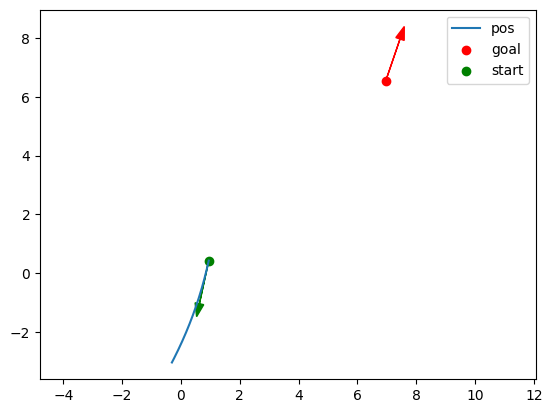

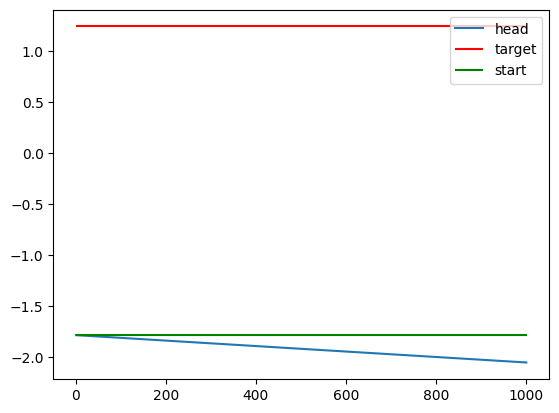

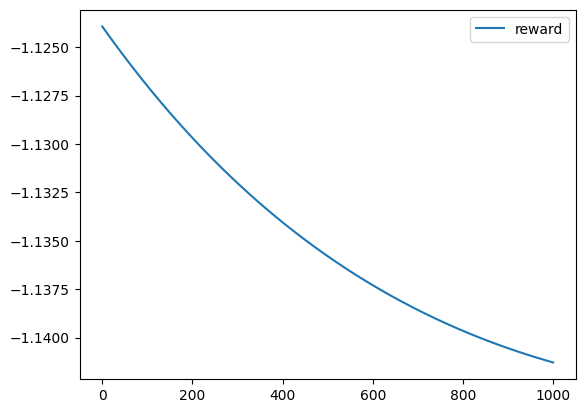

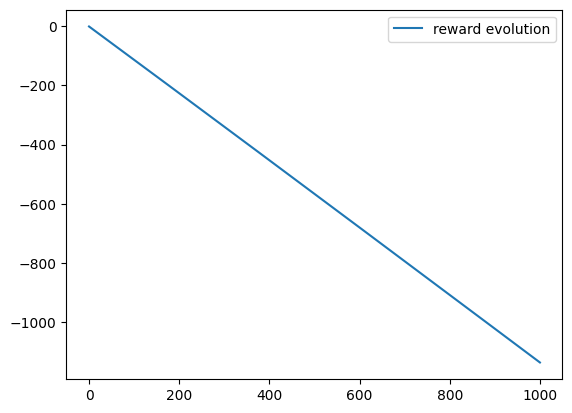

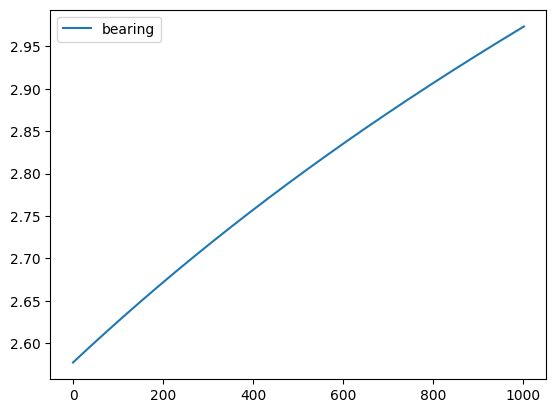

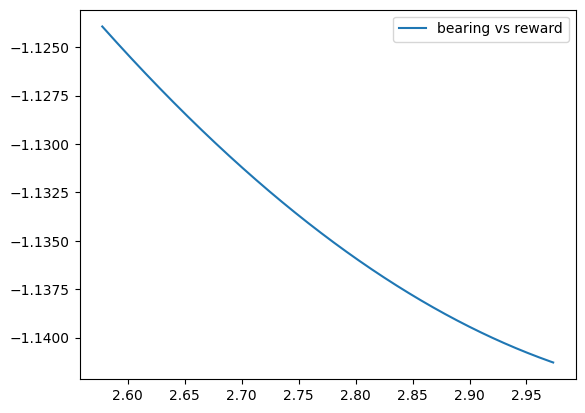

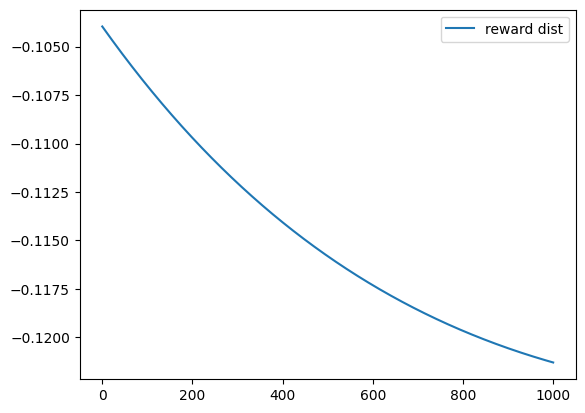

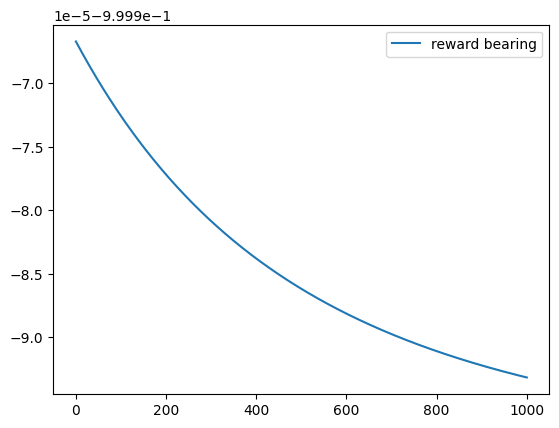

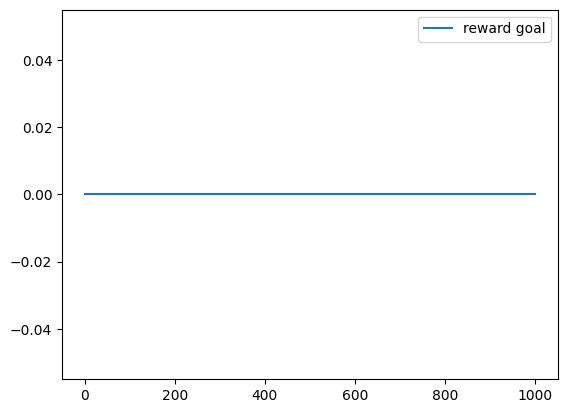

In [16]:

robot = Robot()
np.random.seed(np.random.randint(10))
envs = gym.make("gymnasium_env/ParkingTask-v0")
envs = gym.wrappers.RecordEpisodeStatistics(envs)
envs.unwrapped.robot.max_speed = (1.5, 0.5)
obs, info = envs.reset()


done = False
pos_traj = [envs.unwrapped.start_config[:2].copy()]
orientation_traj = [envs.unwrapped.start_config[2]]
bearing_traj = [envs.unwrapped.bearing.copy()]

rewards_episode = []
rewards_dist = []
rewards_bearing = []  
rewards_orient = []
rewards_goal = []

total_reward = 0
rewards_evolution = []

model = PPO.load("./ppo_parking_task2", env=envs)


while not done:
  action, _ = model.predict(obs, deterministic=True)
  next_obs, rew, terminated, truncated, info = envs.step(action)
  total_reward += rew
  pos_traj.append(envs.unwrapped.robot.config[:2].copy())
  orientation_traj.append(envs.unwrapped.robot.config[2].copy())
  bearing_traj.append(envs.unwrapped.bearing.copy())

  done = terminated or truncated
  rewards_episode.append(rew)
  rewards_evolution.append(total_reward)
  rewards_dist.append(envs.unwrapped.reward_dist)
  rewards_bearing.append(envs.unwrapped.reward_bearing)
  rewards_orient.append(envs.unwrapped.reward_orient)
  rewards_goal.append(envs.unwrapped.reward_goal)

print(f"truncate: {truncated} terminate: {terminated} outbound: {envs.unwrapped.timeout} pos: {envs.unwrapped.robot.config}")
print(f"distance to target: {envs.unwrapped.distance_to_target}")
print(f"final time: {envs.unwrapped.time}")
print(f"episode_returns: {envs.episode_returns}")
print(f"episode_length: {envs.episode_lengths}")
import matplotlib.pyplot as plt

def plot_traj():


    plt.figure()
    x, y = zip(*pos_traj)
    plt.plot(x, y, label="pos")
    plt.scatter(envs.unwrapped.target_config[0], envs.unwrapped.target_config[1], c="r", label="goal")
    plt.scatter(envs.unwrapped.start_config[0], envs.unwrapped.start_config[1], c="g", label="start")

    dx_target, dy_target = np.cos(envs.unwrapped.target_config[2]), np.sin(envs.unwrapped.target_config[2])
    dx_start, dy_start = np.cos(envs.unwrapped.start_config[2]), np.sin(envs.unwrapped.start_config[2])
    length = 1.5
    width = 0.3

    plt.arrow(x=envs.unwrapped.target_config[0], y=envs.unwrapped.target_config[1],
              dx=length*dx_target, dy=length*dy_target, color="r", head_width=0.3)
    plt.arrow(x=envs.unwrapped.start_config[0], y=envs.unwrapped.start_config[1],
              dx=length*dx_start, dy=length*dy_start, color="g", head_width=0.3)

    plt.legend()
    plt.axis("equal")

    plt.figure()
    plt.plot(orientation_traj, label="head")
    plt.hlines(envs.unwrapped.target_config[2:], xmin=0, xmax=len(orientation_traj), colors=["r"], label="target")
    plt.hlines(envs.unwrapped.start_config[2:], xmin=0, xmax=len(orientation_traj), colors=["g"], label="start")
    plt.legend()

plot_traj()

plt.figure()
plt.plot(rewards_episode, label="reward")
plt.legend()

plt.figure()
plt.plot(rewards_evolution, label="reward evolution")
plt.legend()

plt.figure()
plt.plot(bearing_traj, label="bearing")
plt.legend()

plt.figure()
plt.plot(bearing_traj[1:], rewards_episode, label="bearing vs reward")
plt.legend()

plt.figure()
plt.plot(rewards_dist, label="reward dist")
plt.legend()

plt.figure()
plt.plot(rewards_bearing, label="reward bearing")
plt.legend()  

plt.figure()
plt.plot(rewards_goal, label="reward goal")
plt.legend()

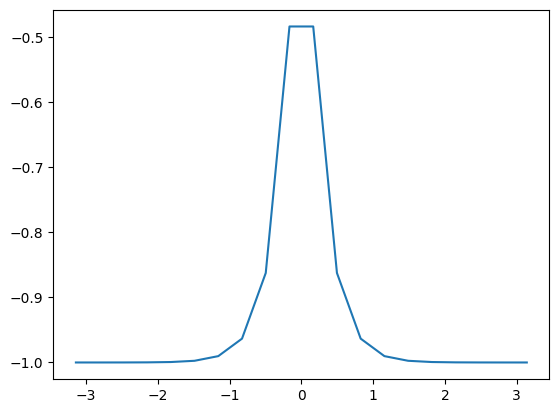

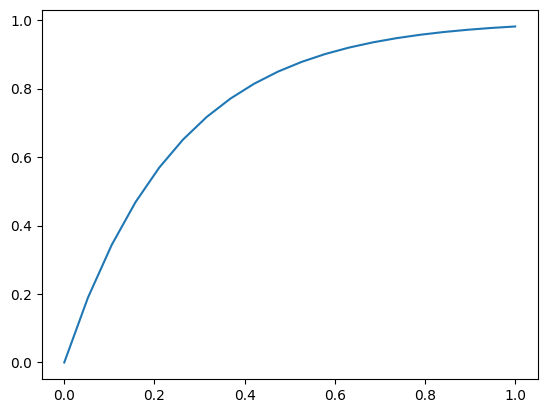

In [ ]:
import matplotlib.pyplot as plt
x = np.linspace(-np.pi, np.pi, 20)
y = np.exp(-4 * np.abs(x)) - 1
plt.figure()
plt.plot(x, y)
x = np.linspace(0, 1, 20)
y = 1-np.exp(-4 * np.abs(x))
plt.figure()
plt.plot(x, y)

In [ ]:
a = [*(3, 2)]
a

[3, 2]